2025-26 Project
You have to work on the Trending YouTube dataset.

Notes
It is mandatory to use GitHub for developing the project.
The project must be a jupyter notebook.
There is no restriction on the libraries that can be used, nor on the Python version.
All questions on the project must be asked in the Discussion forum on the course website.
At most 3 students can be in each group. You must create the groups by yourself. You can use the Discussion forum to create the groups.
You do not have to send me the project before the discussion.
You do not have to prepare any slides for the discussion.
You can use AI tools, but you have to describe in the notebook how you have used such tools and you have to show that you have fully understood everything that you have in your project.
1. Create a single dataframe with the concatenation of all input csv files, adding a column called country
2. Extract all videos that have no tag.
3. For each channel, determine the total number of views
4. Save all rows with disabled comments and disabled ratings, or that have video_error_or_removed in a new dataframe called excluded, and remove those rows from the original dataframe.
5. Add a like_ratio column storing the ratio between the number of likes and of dislikes
6. Cluster the publish time into 10-minute intervals (e.g. from 02:20 to 02:30)
7. For each interval, determine the number of videos, average number of likes and of dislikes.
8. For each tag, determine the number of videos
Notice that tags contains a string with several tags.

9. Find the tags with the largest number of videos
10. For each (tag, country) pair, compute average ratio likes/dislikes
11. For each (trending_date, country) pair, the video with the largest number of views
12. Divide trending_date into three columns: year, month, day
13. For each (month, country) pair, the video with the largest number of views
14. Read all json files with the video categories
15. For each country, determine how many videos have a category that is not assignable.

In [17]:
import pandas as pd
import numpy as np
import glob
import os
import json

In [49]:
path = './data/csv/' 
csv_files = glob.glob(os.path.join(path, "*.csv"))

In [55]:
df_list = []

for filename in csv_files:
    # Read each CSV file
    temp_df = pd.read_csv(filename, encoding='latin-1')  # tried utf-8 but got errors. latin-1 works better for this dataset.
    
    # Extract country code from filename (assuming format like 'USvideos.csv')
    # logic: take the basename, remove extension, and take first 2 chars
    base = os.path.basename(filename)
    country_code = base[0:2].upper() 
    
    temp_df['country'] = country_code
    df_list.append(temp_df)

print(f"Found {len(df_list)} CSV files.")
# Concatenate all dataframes
df = pd.concat(df_list, axis=0, ignore_index=True)

print(f"Dataframe created with shape {df.shape}")
print(df['country'].value_counts())
print(df.head(3))

Found 10 CSV files.
Dataframe created with shape (375942, 17)
country
US    40949
CA    40881
DE    40840
RU    40739
FR    40724
MX    40451
GB    38916
IN    37352
KR    34567
JP    20523
Name: count, dtype: int64
      video_id trending_date  \
0  n1WpP7iowLc      17.14.11   
1  0dBIkQ4Mz1M      17.14.11   
2  5qpjK5DgCt4      17.14.11   

                                               title channel_title  \
0        Eminem - Walk On Water (Audio) ft. BeyoncÃ©    EminemVEVO   
1                      PLUSH - Bad Unboxing Fan Mail     iDubbbzTV   
2  Racist Superman | Rudy Mancuso, King Bach & Le...  Rudy Mancuso   

   category_id              publish_time  \
0           10  2017-11-10T17:00:03.000Z   
1           23  2017-11-13T17:00:00.000Z   
2           23  2017-11-12T19:05:24.000Z   

                                                tags     views   likes  \
0  Eminem|"Walk"|"On"|"Water"|"Aftermath/Shady/In...  17158579  787425   
1  plush|"bad unboxing"|"unboxing"|"fan mail"|"id

In [59]:
# In this dataset, tags are represented as "[none]" string when there are no tags. 
# (Manually checked CAvidoes.csv and found 2385 values with "[none]" tags.)
# (Also DEvideos.csv has 3031 such values.)
videos_no_tags = df[(df['tags'].isna()) | (df['tags'] == '[none]')]
print(f"Step 2: Found {len(videos_no_tags)} videos with no tags.")
print("Percentage of videos with no tags: {:.2f}%".format((len(videos_no_tags) / len(df)) * 100))
print("------------------------------------------")
print("Videos with no tags by country:")
print(videos_no_tags['country'].value_counts())
print("------------------------------------------")
print("Sample videos with no tags:")
print(videos_no_tags[['video_id', 'title', 'country']].head(5))


Step 2: Found 37698 videos with no tags.
Percentage of videos with no tags: 10.03%
------------------------------------------
Videos with no tags by country:
country
MX    7685
KR    7183
FR    5304
RU    3984
JP    3200
DE    3031
CA    2385
GB    2010
US    1535
IN    1381
Name: count, dtype: int64
------------------------------------------
Sample videos with no tags:
       video_id                                              title country
41  JwboxqDylgg  Canada Soccer's Women's National Team v USA In...      CA
58  9B-q8h31Bpk  John Oliver Tackles Louis C.K. And Donald Trum...      CA
78  1UE5Dq1rvUA            Taylor Swift Perform Ready For It - SNL      CA
86  pmJQ4KwliX4  LATEST Q POSTS: ROTHSCHILDS, HOUSE OF SAUD, lL...      CA
98  lHcXhBojpeQ  ä¸å±TVBè¦å¸ï¼ææ£10å¹´éæ¢ç«¹é¦¬é«®å¦...      CA


In [61]:
# ==========================================
# 3. For each channel, determine the total number of views
# ==========================================

channel_views = df.groupby('channel_title')['views'].sum().sort_values(ascending=False)
print("Total views per channel (top 5):\n", channel_views.head())
print("Toal unique channels:", channel_views.shape[0])

Total views per channel (top 5):
 channel_title
ChildishGambinoVEVO     11016766510
Marvel Entertainment    10430605449
NickyJamTV               9479859505
Ozuna                    8623329509
ibighit                  8205572221
Name: views, dtype: int64
Toal unique channels: 37824


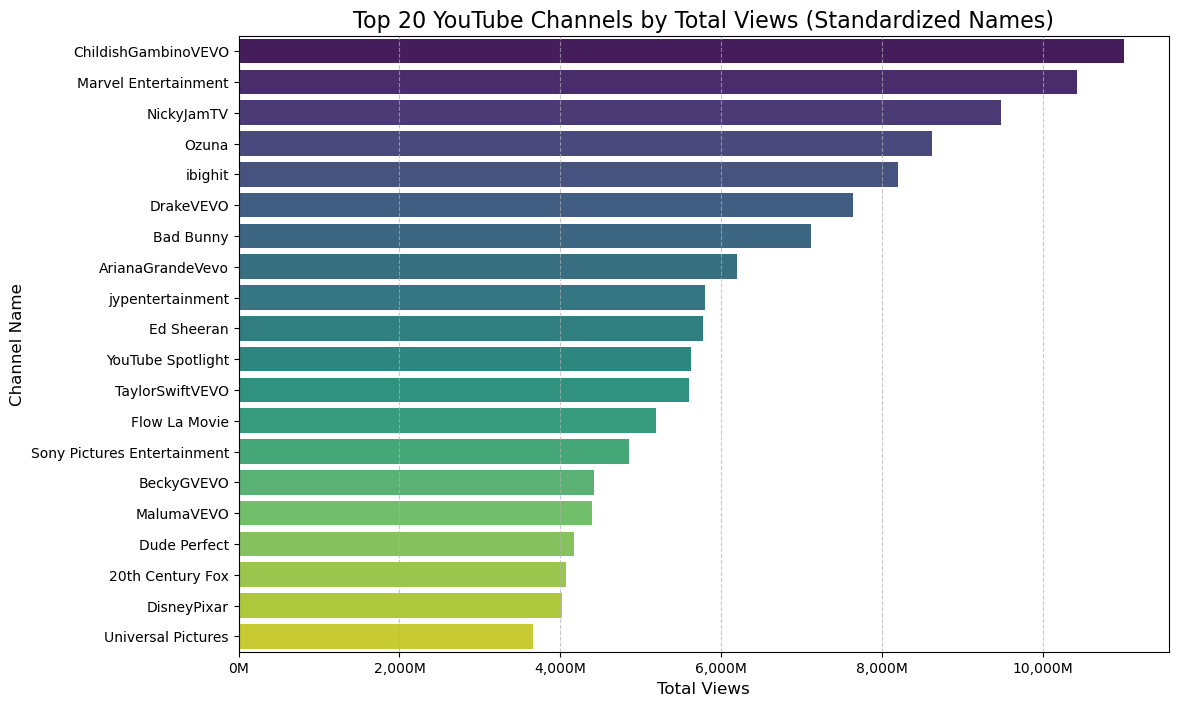

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

# Prepare the data
top_n = 20
top_channels = channel_views.head(top_n).copy()
# Fix for the Seaborn warning about non-ASCII characters
top_channels.index = top_channels.index.astype(str).str.encode('ascii', 'ignore').str.decode('ascii')
# ---------------

# Create the plot
plt.figure(figsize=(12, 8))

# Fix for the Seaborn warning is included here too
sns.barplot(
    x=top_channels.values, 
    y=top_channels.index, 
    hue=top_channels.index, 
    legend=False, 
    palette='viridis'
)

plt.title(f'Top {top_n} YouTube Channels by Total Views (Standardized Names)', fontsize=16)
plt.xlabel('Total Views', fontsize=12)
plt.ylabel('Channel Name', fontsize=12)

# Format X-axis
ax = plt.gca()
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: '{:,.0f}'.format(x/1e6) + 'M'))
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.show()